#### Dataset EDA

Exploration for the AlphaEarth and NLCD wetland sample data. Two parts: the
raw joined table, which does not depend on any generated dataset, and one
generated training pool, chosen below by name. Supersedes the EDA and
"Training pool composition by fold" sections of `gradient_boosting.ipynb`,
which mixed both together with the model training code.


In [1]:
import os
import sys

sys.path.append(os.path.abspath("scripts"))

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.collections import PatchCollection
from matplotlib.colors import to_rgba
from matplotlib.patches import Rectangle

import block_distance_profiles as bdp
import gb_common

pd.set_option("display.max_columns", None)


## Part 1: Raw joined table

Check the joined AlphaEarth and NLCD samples on their own terms, before any
dataset gets built from them: label balance, embedding value ranges, whether
the granule seam problem seen on some coastal tiles during the AlphaEarth
export shows up here, where samples fall geographically, whether
`dist_to_developed_2019_m` behaves the way the labeling scheme implies, and
whether that distance sorts blocks into a small number of regimes.
Queries run against the parquet directory in place with DuckDB instead of
loading all 59M rows into pandas. The joined tiles are 9GB on disk, about
46GB as a dense float32 frame, well past what fits in memory here.


In [2]:
con = gb_common.connect_raw()
con.execute("SELECT COUNT(*) AS n_rows, COUNT(DISTINCT tile_id) AS n_tiles FROM samples").df()


,n_rows,n_tiles
0,59267331,76


### Label balance

This number decides how any dataset built from this table gets split and
weighted for training. Expect "Remained wetland" to dominate heavily, since
conversion is a rare event over a 5 year window.


In [3]:
label_counts = con.execute("""
    SELECT label, label_name, COUNT(*) AS n
    FROM samples
    GROUP BY label, label_name
    ORDER BY label
""").df()
label_counts["frac"] = label_counts["n"] / label_counts["n"].sum()
label_counts


,label,label_name,n,frac
0,0,Remained wetland,58878170,0.993434
1,1,Converted to developed,165908,0.002799
2,2,Converted to other (non-developed),223253,0.003767


### Embedding value range

`export_alphaearth_30m.py` decodes the raw uint8 bands back to `[-1, 1]`
using `OFFSET` and `SCALE_FACTOR`. If the decode or the join went wrong
somewhere, this is the first place it would show: either the range is off,
or a NODATA fill leaked through (the assemble step is supposed to drop
those, not leave them in).


In [4]:
band_bounds = con.execute(f"""
    SELECT MIN(v) AS min_val, MAX(v) AS max_val, COUNT(*) AS n_vals
    FROM samples
    UNPIVOT (v FOR band IN ({", ".join(gb_common.BAND_COLS)}))
""").df()
band_bounds


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_val,max_val,n_vals
0,-0.582677,0.535433,11379327552


### Coastal tile screen

The AlphaEarth export run turned up nondeterminism in the seams between
granules on some coastal tiles. This is a coarse check for whether that
shows up here before trusting the pooled data. Row counts per tile catch a
tile that is missing chunks of coverage. Stats per tile on a single band
(A00_2019, an arbitrary choice) catch a tile whose embedding distribution is
obviously off from its neighbors. This is a screen, not a diagnosis:
anything that stands out here is worth checking against the raw tif before
deciding whether to drop or reprocess that tile.


In [5]:
tile_stats = con.execute("""
    SELECT tile_id,
           COUNT(*) AS n,
           AVG(A00_2019) AS a00_mean,
           STDDEV(A00_2019) AS a00_std,
           MIN(A00_2019) AS a00_min,
           MAX(A00_2019) AS a00_max
    FROM samples
    GROUP BY tile_id
    ORDER BY tile_id
""").df()

# flag tiles whose A00_2019 mean sits far from the mean across tiles: a cheap
# proxy for "this tile's embeddings look systematically different"
overall_mean, overall_std = tile_stats["a00_mean"].mean(), tile_stats["a00_mean"].std()
tile_stats["z"] = (tile_stats["a00_mean"] - overall_mean) / overall_std
tile_stats.reindex(tile_stats["z"].abs().sort_values(ascending=False).index).head(10)


,tile_id,n,a00_mean,a00_std,a00_min,a00_max,z
56,r045_c065,998933,-0.020827,0.078285,-0.283465,0.228346,-2.571493
4,r039_c057,267288,-0.012198,0.065106,-0.283465,0.212598,-2.286117
61,r046_c065,685714,-0.009006,0.070333,-0.259843,0.220472,-2.180544
27,r041_c058,1738110,0.114774,0.058594,-0.259843,0.259843,1.913131
55,r045_c064,1101011,0.003133,0.067856,-0.259843,0.259843,-1.779089
71,r049_c066,373402,0.109925,0.042821,-0.078740,0.236220,1.752770
70,r049_c065,603734,0.109789,0.039290,-0.102362,0.236220,1.748273
3,r039_c056,318066,0.007171,0.066567,-0.275591,0.236220,-1.645534
8,r039_c061,383149,0.105062,0.053716,-0.165354,0.251969,1.591929
36,r042_c060,137280,0.101054,0.049594,-0.118110,0.275591,1.459391


### Spatial distribution

Pull a random sample (small enough to plot, not meant to be representative
of class balance) and check that coverage looks like Florida's wetlands, and
that converted pixels are not clustered somewhere that smells like a
processing artifact rather than real land cover change.


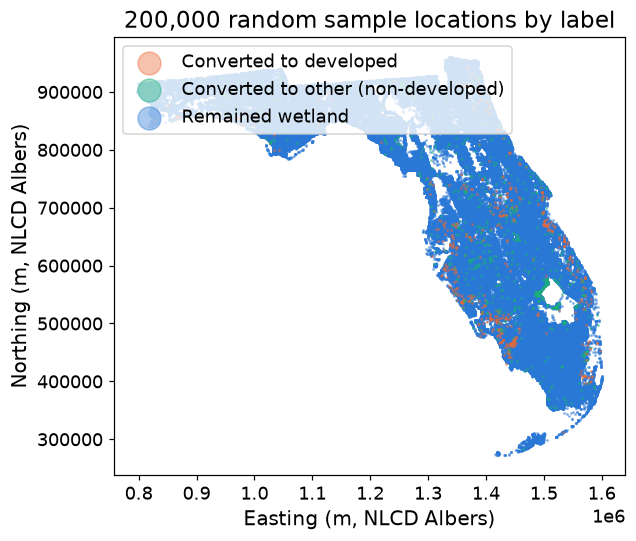

In [6]:
spatial_sample = con.execute("""
    SELECT x, y, label_name
    FROM samples
    USING SAMPLE 200000 ROWS
""").df()

with plt.rc_context(gb_common.SLIDE_RC):
    fig, ax = plt.subplots(figsize=(6, 8))
    for name, grp in spatial_sample.groupby("label_name"):
        # converted classes plotted last, on top, so they aren't buried under
        # the much larger "remained wetland" cloud
        z = 2 if name == "Remained wetland" else 3
        ax.scatter(grp["x"], grp["y"], s=1, alpha=0.4, color=gb_common.LABEL_COLORS[name], label=name, zorder=z)
    ax.set_aspect("equal")
    ax.set_xlabel("Easting (m, NLCD Albers)")
    ax.set_ylabel("Northing (m, NLCD Albers)")
    ax.set_title(f"{len(spatial_sample):,} random sample locations by label")
    ax.legend(markerscale=15, loc="upper left")
    plt.show()


### `dist_to_developed_2019_m` versus label

Distance to the nearest 2019 developed pixel is one of the strongest priors
for conversion risk: proximity to existing development. Pixels that
converted between 2019 and 2024 should sit closer to 2019 development on
average than pixels that stayed wetland. If they do not, that is worth
understanding before this column gets treated as a trustworthy feature.


In [7]:
dist_by_label = con.execute(f"""
    SELECT label_name,
           COUNT(*) AS n,
           AVG({gb_common.DIST_COL}) AS mean_dist_m,
           MEDIAN({gb_common.DIST_COL}) AS median_dist_m
    FROM samples
    GROUP BY label_name
    ORDER BY mean_dist_m
""").df()
dist_by_label


,label_name,n,mean_dist_m,median_dist_m
0,Converted to developed,165908,88.230664,42.426407
1,Converted to other (non-developed),223253,1101.231279,424.264069
2,Remained wetland,58878170,1605.006973,510.000000


In [8]:
# label=0 outnumbers label=1 by about 350 to 1, so one shared linear axis
# would flatten the conversion classes to nothing: bin the distance itself in
# log space instead, since it spans 30m (one AlphaEarth pixel) to over 100km
# and is heavily right skewed
LOG_BIN_WIDTH = 0.05  # 20 bins per decade
DIST_TICKS = [30, 100, 300, 1000, 3000, 10000, 30000, 100000]

dist_hist = con.execute(f"""
    SELECT label_name,
           FLOOR(LOG10({gb_common.DIST_COL}) / {LOG_BIN_WIDTH}) AS bin_idx,
           COUNT(*) AS n
    FROM samples
    GROUP BY label_name, bin_idx
""").df()
dist_hist["left_m"] = 10 ** (dist_hist["bin_idx"] * LOG_BIN_WIDTH)
dist_hist["right_m"] = 10 ** ((dist_hist["bin_idx"] + 1) * LOG_BIN_WIDTH)


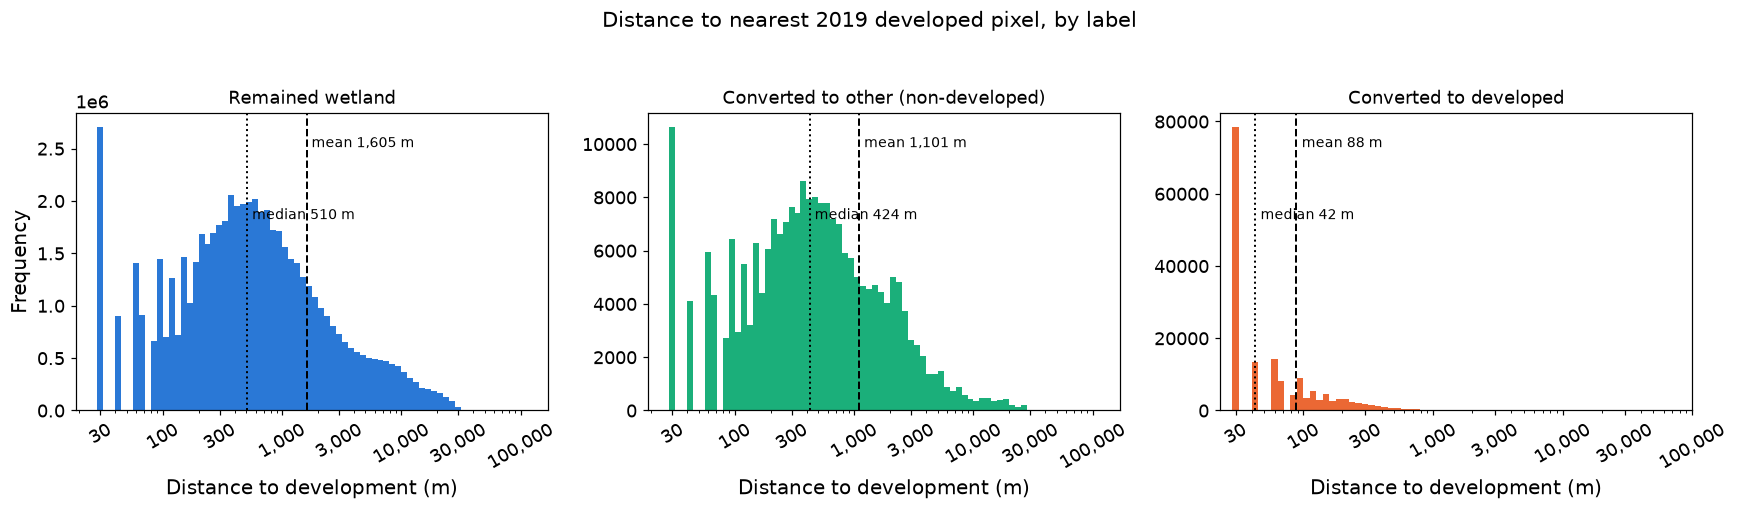

In [9]:
with plt.rc_context(gb_common.SLIDE_RC):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
    for ax, label_name in zip(axes, gb_common.LABEL_COLORS):
        grp = dist_hist[dist_hist["label_name"] == label_name].sort_values("left_m")
        stats = dist_by_label.set_index("label_name").loc[label_name]

        ax.bar(grp["left_m"], grp["n"], width=grp["right_m"] - grp["left_m"],
               align="edge", color=gb_common.LABEL_COLORS[label_name], edgecolor="none")
        ax.set_xscale("log")
        ax.set_xticks(DIST_TICKS)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
        ax.set_xlabel("Distance to development (m)")
        ax.set_title(label_name, fontsize=12)
        ax.tick_params(axis="x", rotation=30)

        ax.axvline(stats["mean_dist_m"], color="black", linestyle="--", linewidth=1.3)
        ax.axvline(stats["median_dist_m"], color="black", linestyle=":", linewidth=1.3)
        ymax = ax.get_ylim()[1]
        ax.text(stats["mean_dist_m"] * 1.1, ymax * 0.92, f"mean {stats['mean_dist_m']:,.0f} m", va="top", fontsize=9)
        ax.text(stats["median_dist_m"] * 1.1, ymax * 0.68, f"median {stats['median_dist_m']:,.0f} m", va="top", fontsize=9)
    axes[0].set_ylabel("Frequency")
    fig.suptitle("Distance to nearest 2019 developed pixel, by label", y=1.03, fontsize=14)
    fig.tight_layout()
    plt.show()


### Block distance regimes

`dist_to_developed_2019_m` is the strongest single feature in every
experiment so far, and the label=0 thinning in `build_train_pool.py pool` is
an exponential decay in it, but it has only ever been looked at per pixel or
per fold. This section asks the per block question: does Florida wetland
fall into a small number of distinct distance regimes, or is it one
continuum? `block_id`, the same 10km partition used for cross validation
below under "Assigning blocks to folds", is the unit.

Each block is reduced to the quantile function of its pixels'
`dist_to_developed_2019_m`, sampled at 39 knots in log10 metres, by
`scripts/block_distance_profiles.py profiles`. Euclidean distance between
two quantile functions is the 2-Wasserstein distance between the
distributions they describe, so k-means over them, run by the same script's
`cluster` command, is Wasserstein k-means: the natural geometry on an
ordered support, and its centroids plot straight back as ECDFs. Run
`profiles`, `cluster`, and `cluster --shape-only` before this cell.
Diagnostic only, nothing here touches the folds, the pool, or the feature
set.


In [10]:
con_blocks = bdp.connect()

block_profiles = bdp.load_profiles()
block_clusters = pd.read_parquet(bdp.clusters_path(shape_only=False))
cluster_sweep = pd.read_csv(bdp.sweep_path(shape_only=False))

blocks = block_profiles.merge(block_clusters, on="block_id")
K = int(blocks["cluster"].max()) + 1
Q = block_profiles[bdp.PROFILE_COLS].to_numpy()

def cluster_label(frame, c):
    g = frame[frame["cluster"] == c]
    return f"cluster {c} (median {np.average(g['q0500'], weights=g['n']):,.0f} m)"

CLUSTER_LABELS = [cluster_label(blocks, c) for c in range(K)]

FIG_DIR = "results/block_clusters"
os.makedirs(FIG_DIR, exist_ok=True)

f"{len(blocks):,} blocks, {blocks['n'].sum():,} pixels, k={K}"


'1,727 blocks, 59,267,331 pixels, k=4'

How many regimes there are comes down to two things: silhouette says how
separated the clusters are, and the resampling ARI says whether the same
partition comes back when 20% of the blocks are dropped. k=2 wins
silhouette outright but only distinguishes near from far, and past k=5 the
ARI starts falling apart, the signal that k-means is cutting through
continuous density rather than finding real gaps. k=4 is the best separated
of the stable options, which is what `DEFAULT_K` in
`block_distance_profiles.py` is set to.


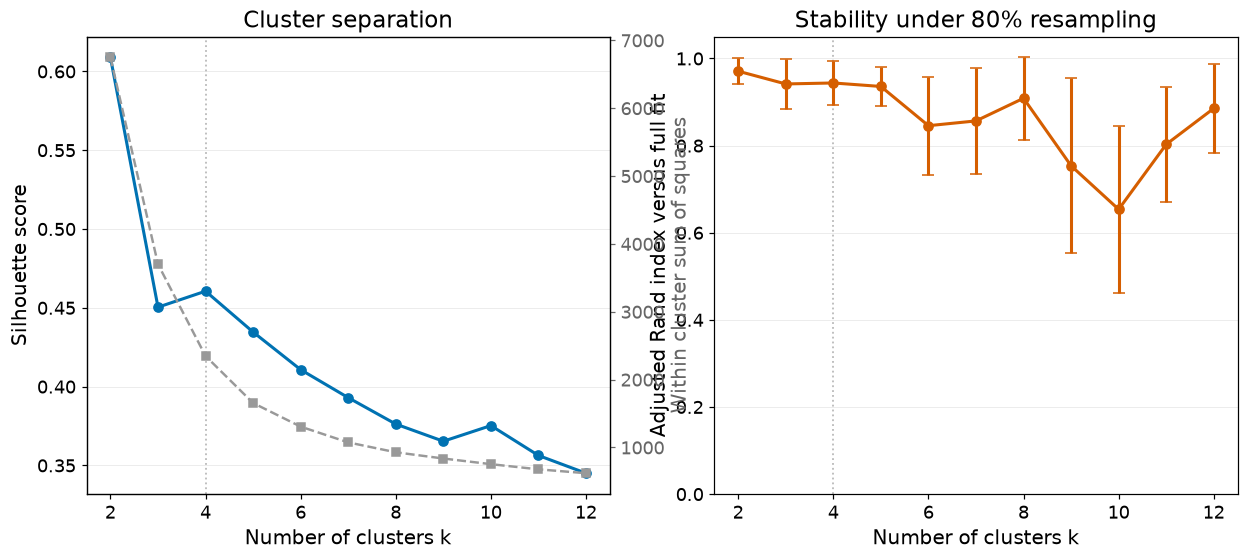

In [11]:
with plt.rc_context(gb_common.SLIDE_RC):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))

    ax = axes[0]
    ax.plot(cluster_sweep["k"], cluster_sweep["silhouette"], marker="o", ms=6, lw=2, color="#0072B2")
    ax.set_xlabel("Number of clusters k")
    ax.set_ylabel("Silhouette score")
    ax.set_title("Cluster separation")
    ax2 = ax.twinx()
    ax2.plot(cluster_sweep["k"], cluster_sweep["inertia"], marker="s", ms=5, lw=1.6, ls="--", color="#999999")
    ax2.set_ylabel("Within cluster sum of squares", color="#666666")
    ax2.tick_params(axis="y", colors="#666666")

    ax = axes[1]
    ax.errorbar(cluster_sweep["k"], cluster_sweep["ari_mean"], yerr=cluster_sweep["ari_std"],
                marker="o", ms=6, lw=2, capsize=4, color="#D55E00")
    ax.set_xlabel("Number of clusters k")
    ax.set_ylabel("Adjusted Rand index versus full fit")
    ax.set_title("Stability under 80% resampling")
    ax.set_ylim(0, 1.05)

    for ax in axes:
        ax.axvline(K, color="#BBBBBB", lw=1.2, ls=":", zorder=0)
        ax.grid(axis="y", alpha=0.25, lw=0.6)
        ax.set_axisbelow(True)

    fig.savefig(f"{FIG_DIR}/cluster_selection.png")
    plt.show()


The heavy line below is each cluster's centroid, itself a valid quantile
function. The band is the 10th to 90th percentile of member blocks at each
knot, so it shows how tightly the members sit around their centroid rather
than implying a confidence interval.


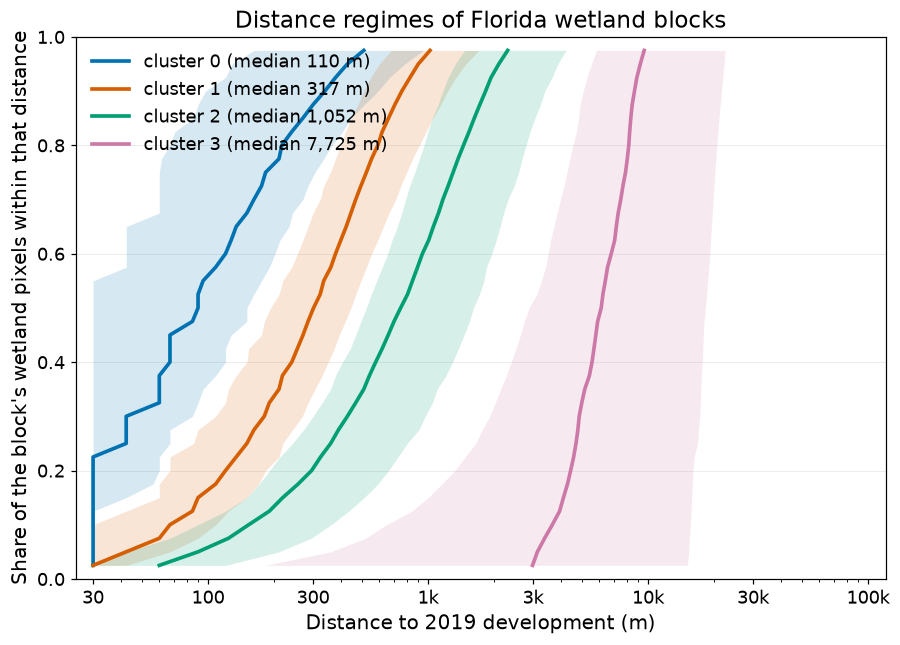

In [12]:
with plt.rc_context(gb_common.SLIDE_RC):
    fig, ax = plt.subplots(figsize=(9.5, 6.4))
    for c in range(K):
        member = (blocks["cluster"] == c).to_numpy()
        lo, mid, hi = np.percentile(Q[member], [10, 50, 90], axis=0)
        ax.fill_betweenx(bdp.P_GRID, lo, hi, color=gb_common.CLUSTER_COLORS[c], alpha=0.16, lw=0)
        ax.plot(mid, bdp.P_GRID, lw=2.4, color=gb_common.CLUSTER_COLORS[c], label=CLUSTER_LABELS[c])

    ax.set_xscale("log")
    ax.set_xlim(25, 120_000)
    ax.set_xticks([30, 100, 300, 1000, 3000, 10_000, 30_000, 100_000])
    ax.set_xticklabels(["30", "100", "300", "1k", "3k", "10k", "30k", "100k"])
    ax.set_ylim(0, 1)
    ax.set_xlabel("Distance to 2019 development (m)")
    ax.set_ylabel("Share of the block's wetland pixels within that distance")
    ax.set_title("Distance regimes of Florida wetland blocks")
    ax.legend(loc="upper left", frameon=False)
    ax.grid(axis="y", alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)

    fig.savefig(f"{FIG_DIR}/cluster_profiles.png")
    plt.show()


The ECDF above hides modes, so the same thing again as densities, binned
straight off the pixels with the same `LOG_BIN_WIDTH` idiom as the label
histogram above. The comb of isolated spikes below about 150m is the
distance transform's lattice, not a data problem: on a 30m square grid the
exact euclidean distance can only land on sqrt(a^2 + b^2) times 30, so the
achievable values start 30, 42, 60, 67, 85, 90 and only fill in once a and b
get large enough for the possibilities to crowd together.


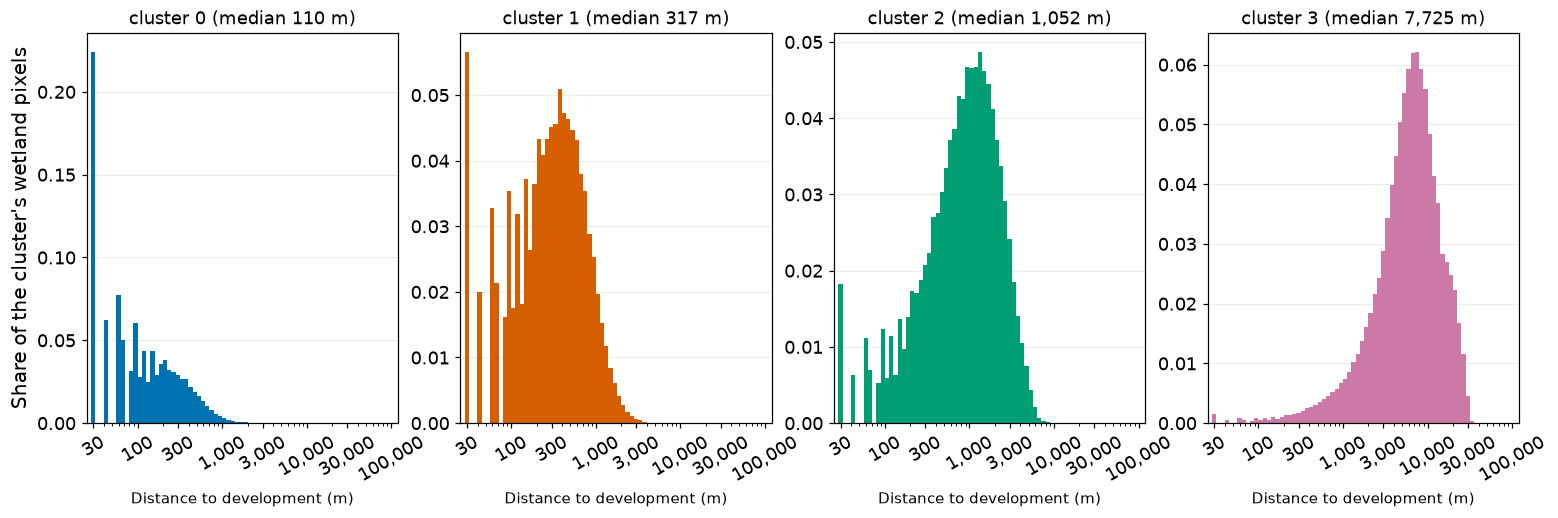

In [13]:
con_blocks.register("blk", blocks[["block_id", "cluster"]])
cluster_hist = con_blocks.execute(f"""
    SELECT b.cluster,
           FLOOR(LOG10(s.{gb_common.DIST_COL}) / {LOG_BIN_WIDTH}) AS bin_idx,
           COUNT(*) AS n
    FROM samples s JOIN blk b USING (block_id)
    GROUP BY b.cluster, bin_idx
""").df()
cluster_hist["left_m"] = 10 ** (cluster_hist["bin_idx"] * LOG_BIN_WIDTH)
cluster_hist["right_m"] = 10 ** ((cluster_hist["bin_idx"] + 1) * LOG_BIN_WIDTH)

with plt.rc_context(gb_common.SLIDE_RC):
    fig, axes = plt.subplots(1, K, figsize=(4.2 * K, 4.6), sharex=True)
    for c, ax in enumerate(axes):
        h = cluster_hist[cluster_hist["cluster"] == c]
        ax.bar(h["left_m"], h["n"] / h["n"].sum(), width=h["right_m"] - h["left_m"],
               align="edge", color=gb_common.CLUSTER_COLORS[c], edgecolor="none")
        ax.set_xscale("log")
        ax.set_xlim(25, 120_000)
        ax.set_xticks(DIST_TICKS)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
        ax.set_xlabel("Distance to development (m)", fontsize=10)
        ax.set_title(CLUSTER_LABELS[c], fontsize=12)
        ax.tick_params(axis="x", rotation=30)
        ax.grid(axis="y", alpha=0.25, lw=0.6)
        ax.set_axisbelow(True)
    axes[0].set_ylabel("Share of the cluster's wetland pixels")

    fig.savefig(f"{FIG_DIR}/cluster_histograms.png")
    plt.show()


Nothing in the clustering sees a coordinate, so the map is the sanity check.
It recovers Florida geography it was never given: cluster 3 is the
Everglades and Big Cypress, cluster 0 tracks the coasts and the Orlando to
Tampa corridor. Blocks under `MIN_BLOCK_PIXELS` (500) are drawn faded, since
their profiles are fit off too few pixels to trust individually.


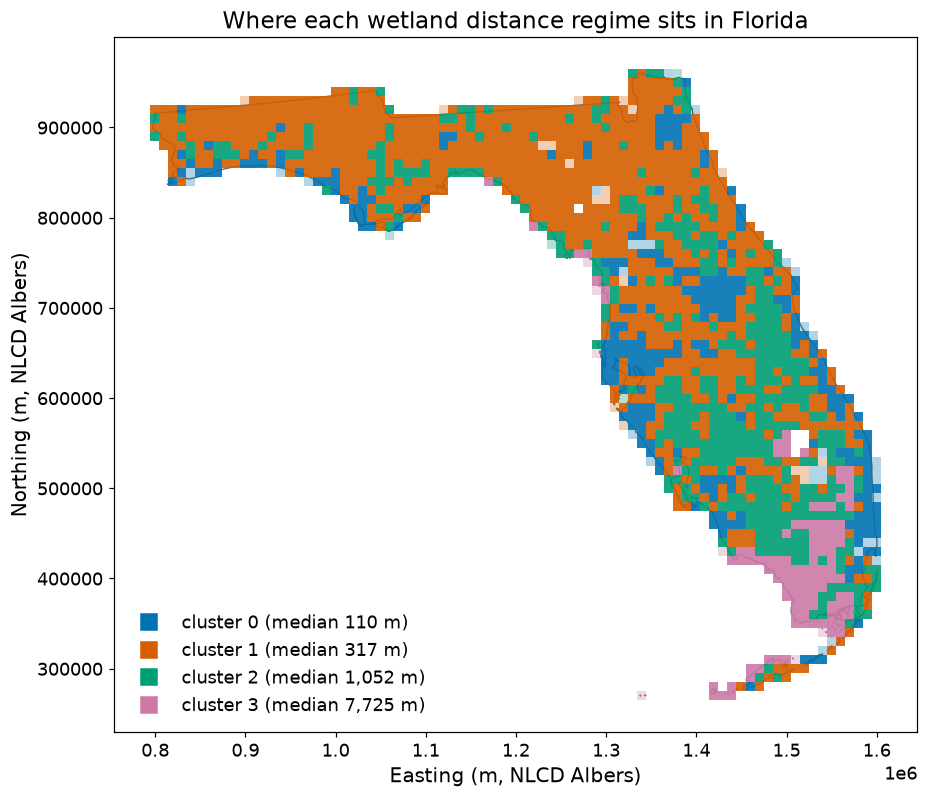

In [14]:
tiles_crs = gpd.read_file("data/boundaries/florida_tiles_30m_60km.gpkg").crs
fl_boundary = gpd.read_file("data/boundaries/cb_2023_us_state_500k/cb_2023_us_state_500k.shp")
fl_boundary = fl_boundary[fl_boundary["STUSPS"] == "FL"].to_crs(tiles_crs)

with plt.rc_context(gb_common.SLIDE_RC):
    fig, ax = plt.subplots(figsize=(10.5, 8.2))
    fl_boundary.boundary.plot(ax=ax, color="#666666", lw=0.9, zorder=1)

    for c in range(K):
        m = blocks["cluster"] == c
        rects = [Rectangle((x - bdp.BLOCK_SIZE_M / 2, y - bdp.BLOCK_SIZE_M / 2),
                           bdp.BLOCK_SIZE_M, bdp.BLOCK_SIZE_M)
                 for x, y in zip(blocks.loc[m, "x_center"], blocks.loc[m, "y_center"])]
        rgba = np.tile(np.array(to_rgba(gb_common.CLUSTER_COLORS[c])), (len(rects), 1))
        rgba[:, 3] = np.where(blocks.loc[m, "is_small"], 0.3, 0.9)
        pc = PatchCollection(rects, edgecolor="none", zorder=2)
        pc.set_facecolor(rgba)
        ax.add_collection(pc)
        ax.plot([], [], "s", ms=10, color=gb_common.CLUSTER_COLORS[c], label=CLUSTER_LABELS[c])

    ax.set_aspect("equal")
    ax.autoscale_view()
    ax.set_xlabel("Easting (m, NLCD Albers)")
    ax.set_ylabel("Northing (m, NLCD Albers)")
    ax.set_title("Where each wetland distance regime sits in Florida")
    ax.legend(loc="lower left", frameon=False)

    fig.savefig(f"{FIG_DIR}/cluster_map.png")
    plt.show()


Whether the regimes mean anything: they do, and the control is what makes
it convincing. Development conversion falls monotonically across the four
regimes and spans a factor of about 380, while conversion to other, not
developed land cover stays flat near 0.4% in every one of them. Distance
regime is picking out where wetland becomes development specifically, not
where wetland is unstable in general.


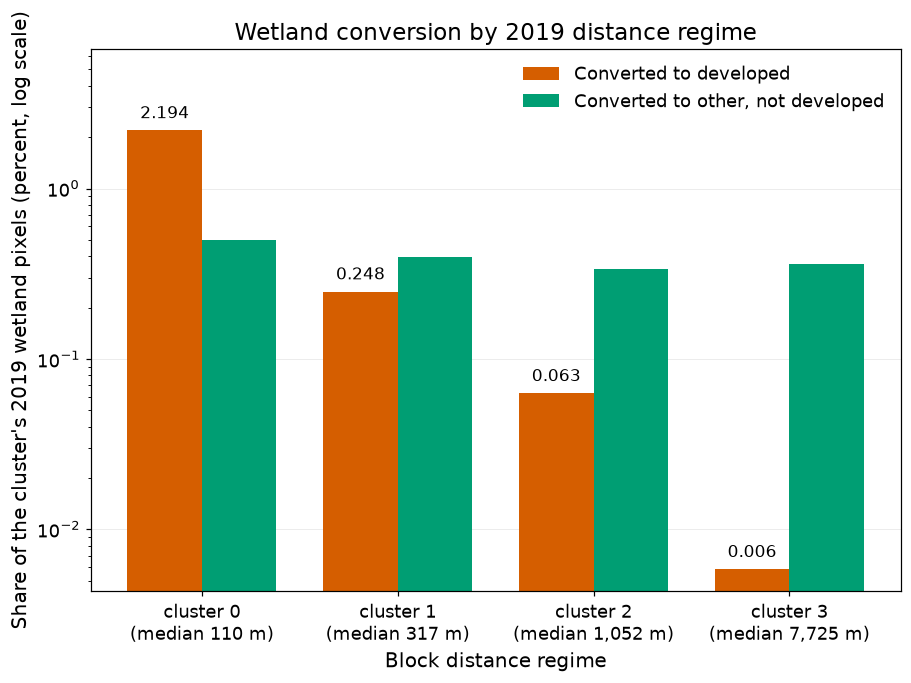

,cluster,blocks,rows,n1,n2,pct1,pct2
0,0,283,3866510,84838.0,19350.0,2.194175,0.500451
1,1,893,27227201,67651.0,107558.0,0.248468,0.395039
2,2,433,20658170,12981.0,69233.0,0.062837,0.335136
3,3,118,7515450,438.0,27112.0,0.005828,0.360750


In [15]:
cluster_rate = blocks.groupby("cluster").agg(
    blocks=("block_id", "size"), rows=("n", "sum"), n1=("n1", "sum"), n2=("n2", "sum")
).reset_index()
cluster_rate["pct1"] = cluster_rate["n1"] / cluster_rate["rows"] * 100
cluster_rate["pct2"] = cluster_rate["n2"] / cluster_rate["rows"] * 100

with plt.rc_context(gb_common.SLIDE_RC):
    fig, ax = plt.subplots(figsize=(9.5, 6.4))
    xs = np.arange(K)
    ax.bar(xs - 0.19, cluster_rate["pct1"], width=0.38, color="#D55E00", label="Converted to developed")
    ax.bar(xs + 0.19, cluster_rate["pct2"], width=0.38, color="#009E73",
           label="Converted to other, not developed")

    for x, v in zip(xs, cluster_rate["pct1"]):
        ax.text(x - 0.19, v * 1.18, f"{v:.3f}", ha="center", fontsize=11)

    ax.set_yscale("log")
    ax.set_ylim(top=cluster_rate[["pct1", "pct2"]].to_numpy().max() * 3)
    ax.set_xticks(xs)
    ax.set_xticklabels([lab.replace(" (", "\n(") for lab in CLUSTER_LABELS])
    ax.set_xlabel("Block distance regime")
    ax.set_ylabel("Share of the cluster's 2019 wetland pixels (percent, log scale)")
    ax.set_title("Wetland conversion by 2019 distance regime")
    ax.legend(loc="upper right", frameon=False)
    ax.grid(axis="y", alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)

    fig.savefig(f"{FIG_DIR}/conversion_rate_by_cluster.png")
    plt.show()

cluster_rate


Is this just binning on median distance? Largely, and that has to be said
plainly. Decomposing every profile into a level and a shape, the level
accounts for 103.9% of the between block variance, the shape 7.9%, and the
covariance between them 11.8% negative, summing to 100. The negative
covariance is itself worth noting: blocks farther from development have
slightly tighter profiles in log space, so level and shape partly cancel.
Clustering the medians alone at k=4 reproduces the full profile partition at
ARI 0.796, so the other 38 knots move roughly a fifth of the blocks and no
more.

Rerunning `cluster --shape-only` subtracts each block's own median first,
isolating whatever is left, and that residual is not nothing. The two shape
clusters below sit at almost the same median distance, 792m and 890m, and
convert at 0.362% versus 0.055%, a factor of 6.6 apart. The separating
feature is the left tail: the higher rate cluster has a p10 of 116m against
228m, so it holds wetland sitting right against a development edge that its
median does not reveal. That is a concrete argument for feeding the model
something about the near tail of a pixel's neighborhood rather than
distance alone, close to what `frac_dev_100m` in the Experiment3 feature
set already does.


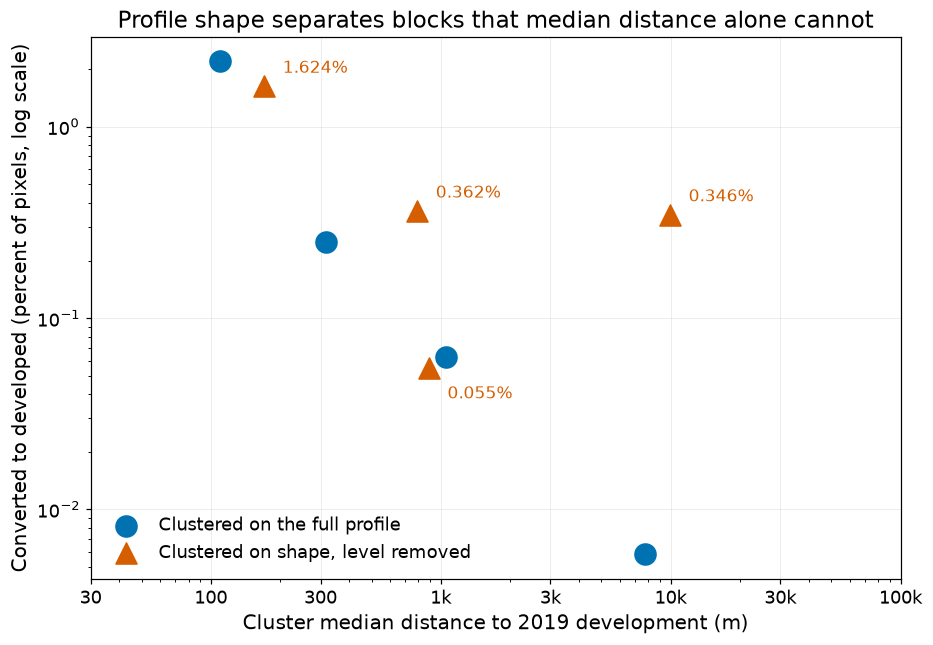

,cluster,rows,n1,pct1,med
0,0,4700757,76356.0,1.624334,170.934397
1,1,34907629,19195.0,0.054988,890.071681
2,2,15145797,54754.0,0.361513,791.897600
3,3,4513148,15603.0,0.345723,9964.520181


In [16]:
shape_clusters = pd.read_parquet(bdp.clusters_path(shape_only=True))
shape_blocks = block_profiles.merge(shape_clusters, on="block_id")

def cluster_rates(frame):
    out = frame.groupby("cluster").agg(rows=("n", "sum"), n1=("n1", "sum")).reset_index()
    out["pct1"] = out["n1"] / out["rows"] * 100
    out["med"] = [np.average(frame.loc[frame["cluster"] == c, "q0500"],
                             weights=frame.loc[frame["cluster"] == c, "n"]) for c in out["cluster"]]
    return out

full_rate, shape_rate = cluster_rates(blocks), cluster_rates(shape_blocks)

with plt.rc_context(gb_common.SLIDE_RC):
    fig, ax = plt.subplots(figsize=(9.5, 6.4))
    ax.scatter(full_rate["med"], full_rate["pct1"], s=190, color="#0072B2", marker="o",
               label="Clustered on the full profile", zorder=3)
    ax.scatter(shape_rate["med"], shape_rate["pct1"], s=190, color="#D55E00", marker="^",
               label="Clustered on shape, level removed", zorder=3)

    # Label above or below depending on what the point would otherwise collide with.
    for _, r in shape_rate.iterrows():
        dy = -20 if r["pct1"] < 0.1 else 9
        ax.annotate(f"{r['pct1']:.3f}%", (r["med"], r["pct1"]), textcoords="offset points",
                    xytext=(12, dy), fontsize=11, color="#D55E00")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xticks([30, 100, 300, 1000, 3000, 10_000, 30_000, 100_000])
    ax.set_xticklabels(["30", "100", "300", "1k", "3k", "10k", "30k", "100k"])
    ax.set_xlabel("Cluster median distance to 2019 development (m)")
    ax.set_ylabel("Converted to developed (percent of pixels, log scale)")
    ax.set_title("Profile shape separates blocks that median distance alone cannot")
    ax.legend(loc="lower left", frameon=False)
    ax.grid(alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)

    fig.savefig(f"{FIG_DIR}/level_versus_shape.png")
    plt.show()

shape_rate


One thing worth carrying forward, checked here against baseline-v1's fold
assignment since Part 2 below has not chosen a dataset yet: the existing
folds balance block count,
rows, and label=1 and label=2 counts, but nothing about distance regime,
and they come out uneven on it. Cluster 3 ranges from 16 to 31 blocks
across the five folds and cluster 0 from 41 to 70, close to a factor of two
either way. Not obviously a problem, since the fold balance that matters
for comparing per fold AP is the positive count, which is already tight,
but worth knowing about when a per fold metric moves and the explanation is
not obvious from the label counts.


In [17]:
fold_check_blocks = pd.read_parquet("data/processed/datasets/baseline-v1/block_folds.parquet")
cluster_by_fold = blocks.merge(fold_check_blocks[["block_id", "fold"]], on="block_id")
cluster_fold_ct = pd.crosstab(cluster_by_fold["cluster"], cluster_by_fold["fold"])
display(cluster_fold_ct)
print((cluster_fold_ct.max(axis=1) / cluster_fold_ct.min(axis=1)).rename("max over min blocks per fold").to_string())


fold,0,1,2,3,4
cluster,,,,,
0,54,57,70,41,61
1,166,188,189,193,157
2,95,79,66,95,98
3,31,22,20,16,29


cluster
0    1.707317
1    1.229299
2    1.484848
3    1.937500


## Part 2: Training pool

Everything below is EDA on one generated dataset, the fold assignment and
weighted training pool `scripts/build_train_pool.py` writes to
`data/processed/datasets/<DATASET_NAME>/`. Set `DATASET_NAME` to whichever
dataset was just built (or already exists) to inspect it. Nothing here
writes anything: this is a read only look at what a dataset build produced.


In [18]:
DATASET_NAME = "baseline-v1"

con_pool, block_folds = gb_common.connect_samples(DATASET_NAME)
train_pool = gb_common.load_train_pool(DATASET_NAME)
dataset_config = gb_common.load_dataset_config(DATASET_NAME)
dataset_config


{'dataset_name': 'baseline-v1',
 'draw_seed': 42,
 'k_folds': 5,
 'p_floor': 0.01,
 'pos_row_dup': 2,
 'pos_weight_mult': 10.0,
 'rows_per_fold': 625000,
 'rows_per_training_set': 2500000,
 'seed': 0,
 'tau_m': 200.0}

### Assigning blocks to folds

`block_id` (about 10km cells, baked in by `join_alphaearth_samples.py`'s
`add_block_id`) exists so spatially correlated neighboring pixels do not
straddle a train and test boundary. `scripts/build_train_pool.py folds`
balances three things at once instead of just positives: block count, the
label=1 and label=2 counts, and total rows.


In [19]:
block_folds.groupby("fold").agg(
    blocks=("block_id", "size"), rows=("n", "sum"), n1=("n1", "sum"), n2=("n2", "sum")
)


,blocks,rows,n1,n2
fold,,,,
0,346,11853460,33181.0,44650.0
1,346,11853459,33182.0,44651.0
2,345,11853454,33181.0,44651.0
3,345,11853498,33182.0,44650.0
4,345,11853460,33182.0,44651.0


### Pool integrity

A pool drawn against a superseded `block_folds.parquet` would still load
fine and silently train on the wrong split, so this checks the parts that
would differ rather than trusting the file blindly.


In [20]:
pool_blocks = train_pool[["block_id", "fold"]].drop_duplicates()
assert pool_blocks.merge(block_folds[["block_id", "fold"]], on=["block_id", "fold"]).shape[0] == len(pool_blocks), \
    "pool fold assignment disagrees with block_folds.parquet, rerun build_train_pool.py"
assert (train_pool.loc[train_pool["label"] == 1, "sample_weight"]
        == dataset_config["pos_weight_mult"] / dataset_config["pos_row_dup"]).all()

len(train_pool), train_pool[gb_common.TARGET_COL].mean()


(3126041, np.float64(0.10614576072418756))

### Per fold training set size and weight share

Two numbers describe this pool and they disagree by roughly four times. By
row count it is around 10% positive. By weight, which is what LightGBM
actually optimizes since it accumulates weighted gradients and hessians, it
is closer to 3%. The row figure is the misleading one.


In [21]:
pool_rows_by_fold = train_pool.groupby("fold").size().rename("pool_rows")
fold_sizes = pd.DataFrame({
    "pool_rows_held_out": pool_rows_by_fold,
    "training_rows": len(train_pool) - pool_rows_by_fold,
})
display(fold_sizes)

flagged = train_pool.assign(
    is_pos=(train_pool["label"] == 1).astype(float),
    pos_w=train_pool["sample_weight"].where(train_pool["label"] == 1, 0.0),
)
share = flagged.groupby("fold").agg(
    rows_pct=("is_pos", "mean"),
    pos_weight=("pos_w", "sum"),
    total_weight=("sample_weight", "sum"),
    mean_weight=("sample_weight", "mean"),
)
share["rows_pct"] *= 100
share["weight_pct"] = 100 * share["pos_weight"] / share["total_weight"]
share[["rows_pct", "weight_pct", "mean_weight"]]


,pool_rows_held_out,training_rows
fold,,
0,625440,2500601
1,623497,2502544
2,625159,2500882
3,626078,2499963
4,625867,2500174


,rows_pct,weight_pct,mean_weight
fold,,,
0,10.610450,2.732492,19.415335
1,10.643836,2.733559,19.468822
2,10.615219,2.732819,19.421739
3,10.599957,2.723223,19.462154
4,10.603531,2.727733,19.436525


### Fold distance profile, natural versus pool

The ECDF is read straight off quantiles rather than by pulling 59M distances
into pandas: 199 evenly spaced quantiles per fold trace the same curve. The
left panel is each fold as it naturally occurs in Florida; the right panel
is after the distance weighted draw thinned label=0 rows down to the
training pool.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

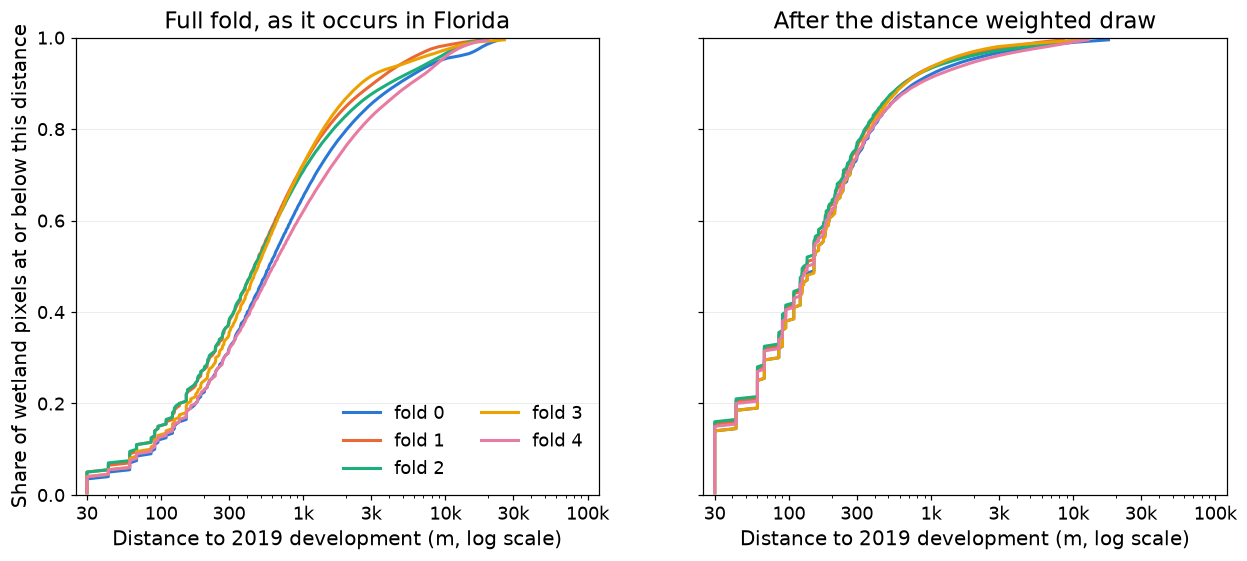

In [22]:
ECDF_PROBS = [i / 200 for i in range(1, 200)]
_probs_sql = "[" + ", ".join(f"{p:.5f}" for p in ECDF_PROBS) + "]"

natural_ecdf = con_pool.execute(f"""
    SELECT fold, QUANTILE_CONT({gb_common.DIST_COL}, {_probs_sql}) AS xs
    FROM samples_fold WHERE label = 0
    GROUP BY fold ORDER BY fold
""").df()

pool_ecdf = (
    train_pool[train_pool["label"] == 0]
    .groupby("fold")[gb_common.DIST_COL]
    .quantile(ECDF_PROBS)
    .unstack(level=-1)
)

with plt.rc_context(gb_common.SLIDE_RC):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), sharey=True)
    for k in range(gb_common.K_FOLDS):
        axes[0].plot(natural_ecdf.loc[natural_ecdf["fold"] == k, "xs"].iloc[0], ECDF_PROBS,
                     color=gb_common.FOLD_COLORS[k], lw=2, label=f"fold {k}")
        axes[1].plot(pool_ecdf.loc[k].to_numpy(), ECDF_PROBS,
                     color=gb_common.FOLD_COLORS[k], lw=2, label=f"fold {k}")

    axes[0].set_title("Full fold, as it occurs in Florida")
    axes[1].set_title("After the distance weighted draw")
    axes[0].set_ylabel("Share of wetland pixels at or below this distance")
    for ax in axes:
        ax.set_xscale("log")
        ax.set_xlim(25, 120_000)
        ax.set_xlabel("Distance to 2019 development (m, log scale)")
        ax.set_xticks([30, 100, 300, 1000, 3000, 10_000, 30_000, 100_000])
        ax.set_xticklabels(["30", "100", "300", "1k", "3k", "10k", "30k", "100k"])
        ax.grid(axis="y", alpha=0.25, lw=0.6)
        ax.set_axisbelow(True)
    axes[0].set_ylim(0, 1)
    axes[0].legend(loc="lower right", frameon=False, ncol=2)
    plt.show()


### Pool composition by fold

The block balancing above evened out raw block counts and positive counts
before any sampling happened. The distance weighted draw then thinned
label=0 rows nonuniformly, which could in principle throw that balance off
again if one fold's blocks happen to sit at systematically different
distances from development than another's. This checks the artifact that
actually gets trained on.


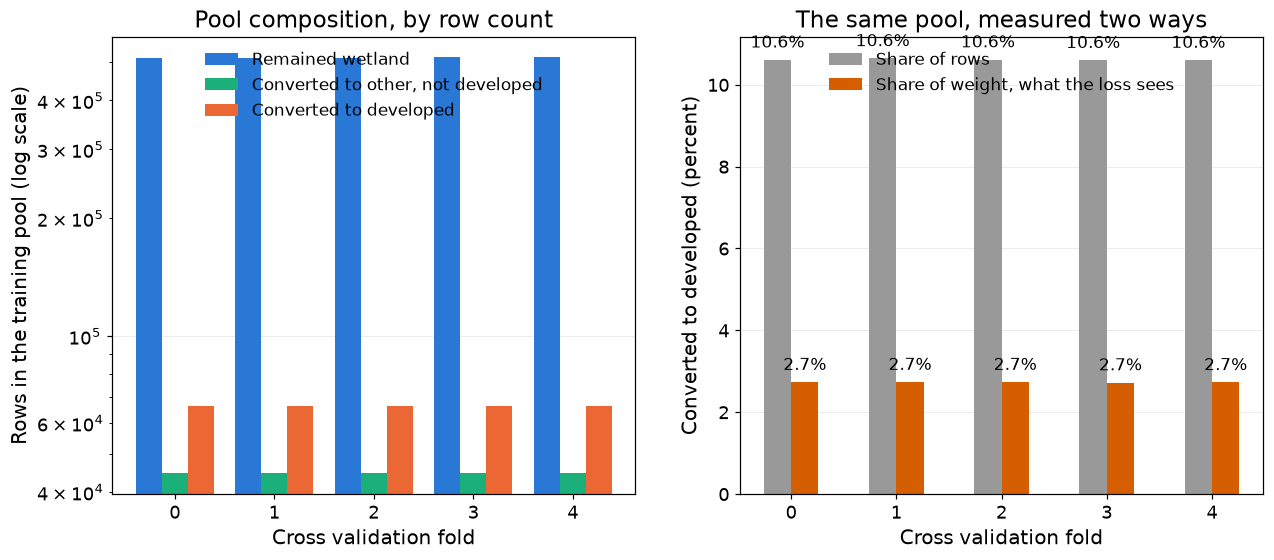

In [23]:
pool_counts = (
    train_pool.groupby(["fold", "label"]).size().unstack(fill_value=0)
    .rename(columns={0: "Remained wetland", 1: "Converted to developed",
                     2: "Converted to other, not developed"})
)
CLASS_COLORS = {"Remained wetland": gb_common.LABEL_COLORS["Remained wetland"],
                "Converted to other, not developed": gb_common.LABEL_COLORS["Converted to other (non-developed)"],
                "Converted to developed": gb_common.LABEL_COLORS["Converted to developed"]}

with plt.rc_context(gb_common.SLIDE_RC):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))

    width, folds = 0.26, np.arange(gb_common.K_FOLDS)
    for i, name in enumerate(CLASS_COLORS):
        axes[0].bar(folds + (i - 1) * width, pool_counts[name], width,
                    color=CLASS_COLORS[name], label=name)
    axes[0].set_yscale("log")
    axes[0].set_xticks(folds)
    axes[0].set_xlabel("Cross validation fold")
    axes[0].set_ylabel("Rows in the training pool (log scale)")
    axes[0].set_title("Pool composition, by row count")
    axes[0].legend(loc="upper center", frameon=False, fontsize=11, ncol=1)
    axes[0].grid(axis="y", alpha=0.25, lw=0.6)
    axes[0].set_axisbelow(True)

    axes[1].bar(folds - width / 2, share["rows_pct"], width, color="#999999", label="Share of rows")
    axes[1].bar(folds + width / 2, share["weight_pct"], width, color="#D55E00",
                label="Share of weight, what the loss sees")
    for k in folds:
        axes[1].text(k - width / 2, share["rows_pct"].iloc[k] + 0.3, f"{share['rows_pct'].iloc[k]:.1f}%",
                     ha="center", fontsize=11)
        axes[1].text(k + width / 2, share["weight_pct"].iloc[k] + 0.3, f"{share['weight_pct'].iloc[k]:.1f}%",
                     ha="center", fontsize=11)
    axes[1].set_xticks(folds)
    axes[1].set_xlabel("Cross validation fold")
    axes[1].set_ylabel("Converted to developed (percent)")
    axes[1].set_title("The same pool, measured two ways")
    axes[1].legend(loc="upper center", frameon=False, fontsize=11)
    axes[1].grid(axis="y", alpha=0.25, lw=0.6)
    axes[1].set_axisbelow(True)
    plt.show()


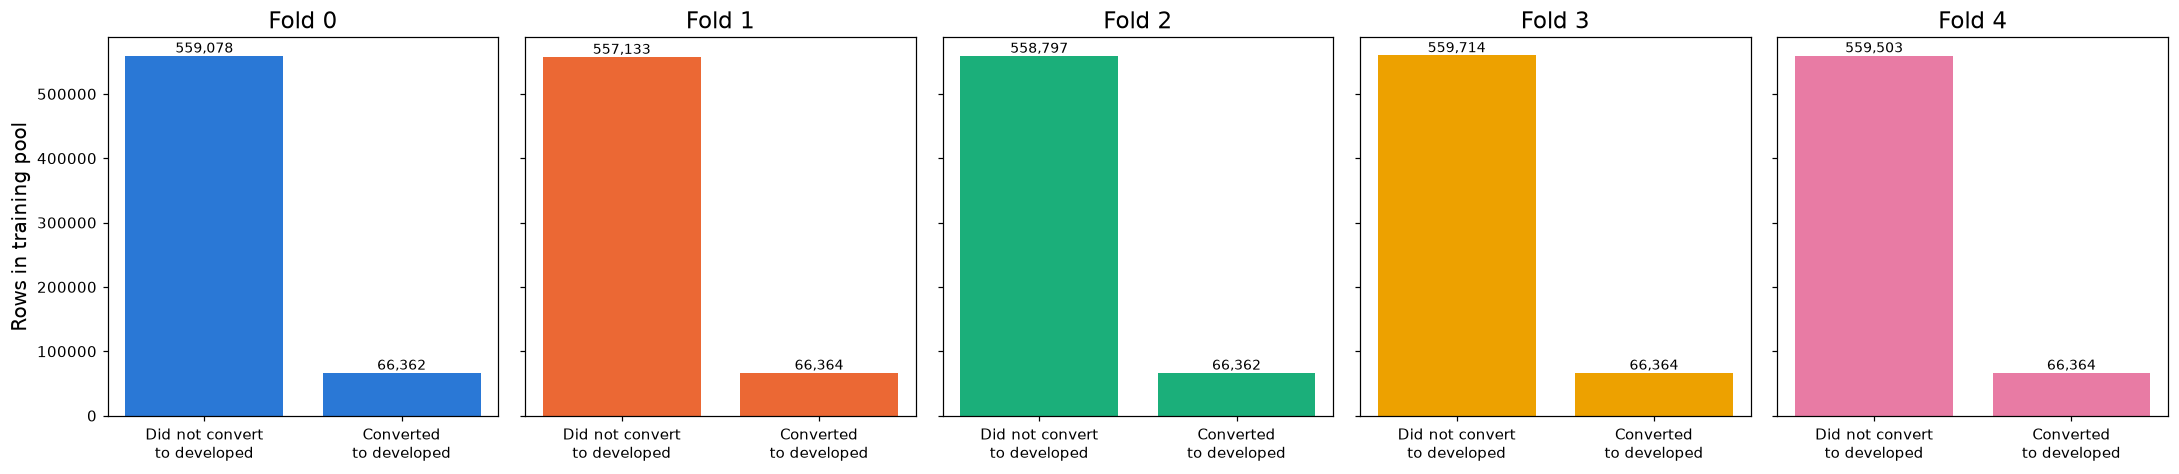

In [24]:
fold_label_counts = train_pool.groupby(["fold", gb_common.TARGET_COL]).size().rename("n").reset_index()
categories = ["Did not convert\nto developed", "Converted\nto developed"]

with plt.rc_context(gb_common.SLIDE_RC):
    fig, axes = plt.subplots(1, gb_common.K_FOLDS, figsize=(4 * gb_common.K_FOLDS, 4.5), sharey=True)
    for fold_id, ax in enumerate(axes):
        grp = fold_label_counts[fold_label_counts["fold"] == fold_id].set_index(gb_common.TARGET_COL)["n"]
        counts = [grp.get(0, 0), grp.get(1, 0)]
        bars = ax.bar(categories, counts, color=gb_common.FOLD_COLORS[fold_id])
        ax.set_title(f"Fold {fold_id}")
        ax.tick_params(labelsize=10)
        for bar, c in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{c:,}",
                    ha="center", va="bottom", fontsize=9)
    axes[0].set_ylabel("Rows in training pool")
    fig.tight_layout()
    plt.show()


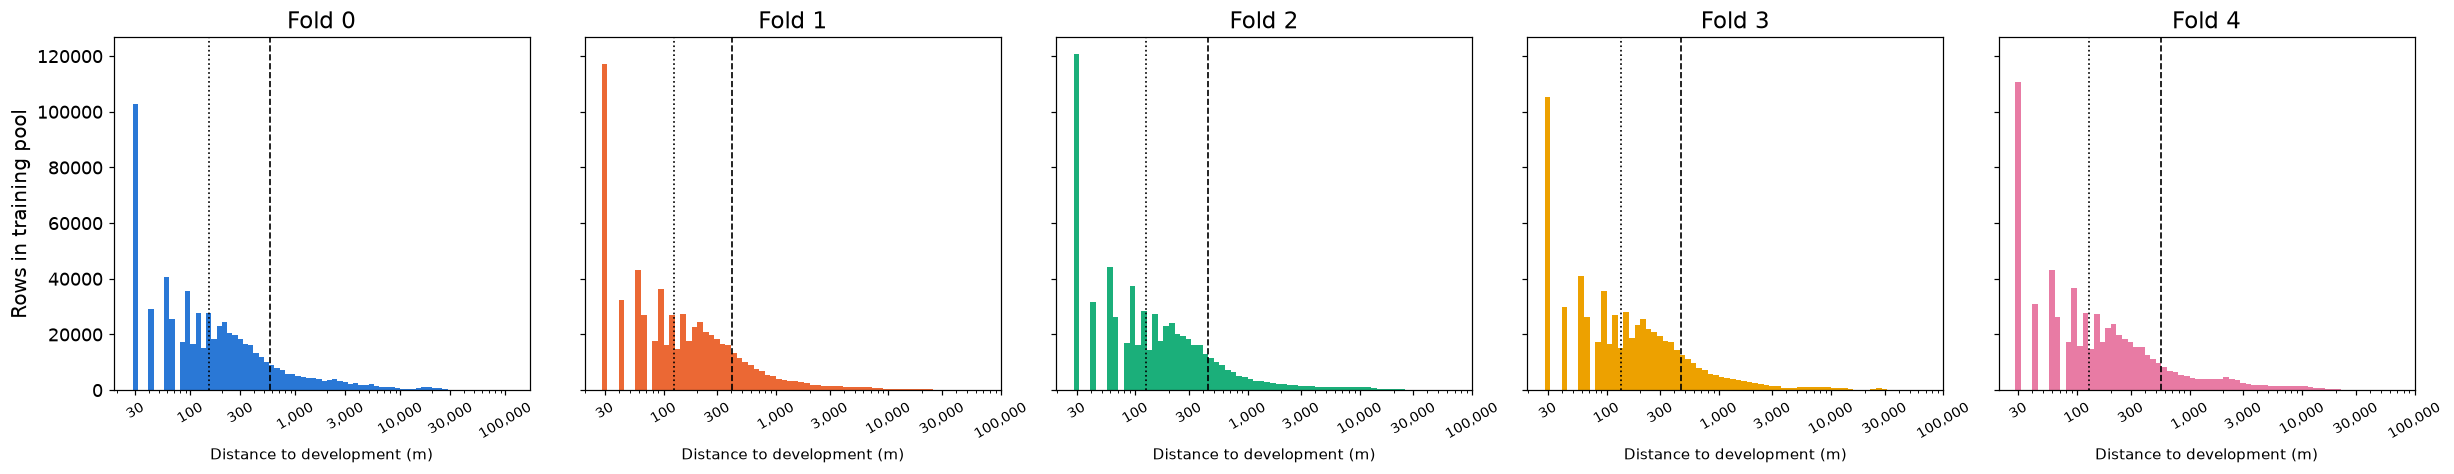

In [25]:
bin_idx = np.floor(np.log10(train_pool[gb_common.DIST_COL]) / LOG_BIN_WIDTH)
fold_dist_hist = (
    pd.DataFrame({"fold": train_pool["fold"], "bin_idx": bin_idx})
    .groupby(["fold", "bin_idx"]).size().rename("n").reset_index()
)
fold_dist_hist["left_m"] = 10 ** (fold_dist_hist["bin_idx"] * LOG_BIN_WIDTH)
fold_dist_hist["right_m"] = 10 ** ((fold_dist_hist["bin_idx"] + 1) * LOG_BIN_WIDTH)

with plt.rc_context(gb_common.SLIDE_RC):
    fig, axes = plt.subplots(1, gb_common.K_FOLDS, figsize=(4.5 * gb_common.K_FOLDS, 4.5), sharey=True)
    for fold_id, ax in enumerate(axes):
        grp = fold_dist_hist[fold_dist_hist["fold"] == fold_id].sort_values("left_m")
        dist_vals = train_pool.loc[train_pool["fold"] == fold_id, gb_common.DIST_COL]
        mean_d, median_d = dist_vals.mean(), dist_vals.median()

        ax.bar(grp["left_m"], grp["n"], width=grp["right_m"] - grp["left_m"],
               align="edge", color=gb_common.FOLD_COLORS[fold_id], edgecolor="none")
        ax.set_xscale("log")
        ax.set_xticks(DIST_TICKS)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
        ax.set_xlabel("Distance to development (m)", fontsize=10)
        ax.set_title(f"Fold {fold_id}")
        ax.axvline(mean_d, color="black", linestyle="--", linewidth=1.1)
        ax.axvline(median_d, color="black", linestyle=":", linewidth=1.1)
        ax.tick_params(labelsize=9, axis="x", rotation=30)
    axes[0].set_ylabel("Rows in training pool")
    fig.tight_layout()
    plt.show()
